In [1]:
import os
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/dataset')
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/')
from dataset.dataset_utils import *
from model.ES_net_mixer import *
from model import LightingModel
from torch.utils.data import DataLoader
import torch.nn.functional as F
import lightning as L
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
from inference_utils import *

In [2]:
train_dataset, val_dataset= get_dataset(
        data_dir="/home/linhang/workbench/Earthquake_data/",
        window_size=140,
        forecast_horizon=14,
        lape_dim=30,
        geo_percentage=0.3,
        sem_percentage=0.3,
        time_resolution=14,
        earthquake_catalog_window=1400,
        train_percentage=0.9,
        start_date="2017-01-01",
        last_date="2024-01-01",
        val_date="2021-09-04" 
        )

GNSS Data Length: 2402
Earthquake Data Length: 2402
使用日期 2021-09-04 划分验证集。


In [3]:
len(train_dataset), len(val_dataset)

(1554, 848)

In [ ]:
# model_dir = "/home/linhang/workbench/workbench/Earthquake_predictor/Result/"
# with open("Result/Pretrain_ES_net_mixer_california/Hyperparameters/model_params.json", 'r') as f:
#     model_par = json.load(f)
# model = LightingModel(model = ES_net_mixer, lr = None, max_epoch=None,loss_fns=None,**model_par).to("cuda:0")
# model.initial_model("Result/Pretrain_ES_net_mixer_california/checkpoints/Val-epoch=01-val_loss=0.47.ckpt").to("cuda:2")
# model.eval()
model = LightingModel.load_from_checkpoint("/home/linhang/workbench/workbench/Earthquake_predictor/Result/Scratch/Scratch_ES_net_mixer_california_Light/checkpoints/last.ckpt",map_location=torch.device("cuda:2"))
def count_model_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print("count_model_parameters:",count_model_parameters(model.model))
model.eval()

LightingModel(
  (model): Mlpbaseline(
    (earthquake_mlp): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=100, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): ReLU()
      (6): Dropout(p=0.3, inplace=False)
    )
    (gnss_mlp): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=1120, out_features=256, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): ReLU()
      (6): Dropout(p=0.3, inplace=False)
    )
    (output_mlp): Sequential(
      (0): Linear(in_features=512, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
      (3): Linear(in_features=256, out_features=1, bias=True)
    )
  )
  (nnse_loss): NNSELoss()
)

576001

In [5]:

train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=False, collate_fn=train_dataset.collate_fn,num_workers=64
)
val_loader = DataLoader(
    val_dataset, batch_size=4, shuffle=False, collate_fn=val_dataset.collate_fn,num_workers=64
)


In [6]:
use_loader = train_loader

In [7]:
sample_batch = next(iter(use_loader))


with torch.no_grad():
    predictions = model.predict_step(sample_batch, 0)


In [8]:
earthquake_history_topk,earthquake_future_topk,energy_predict,topk_index = find_activate_area(sample_batch['log_energy_history'][0],predictions['log_energy_future'][0],predictions['energy_predict'][0],9)

In [9]:
earthquake_location_topk = np.round(denormalize_locations(predictions['earthquake_location'][0][topk_index]).detach().cpu().numpy(),2)

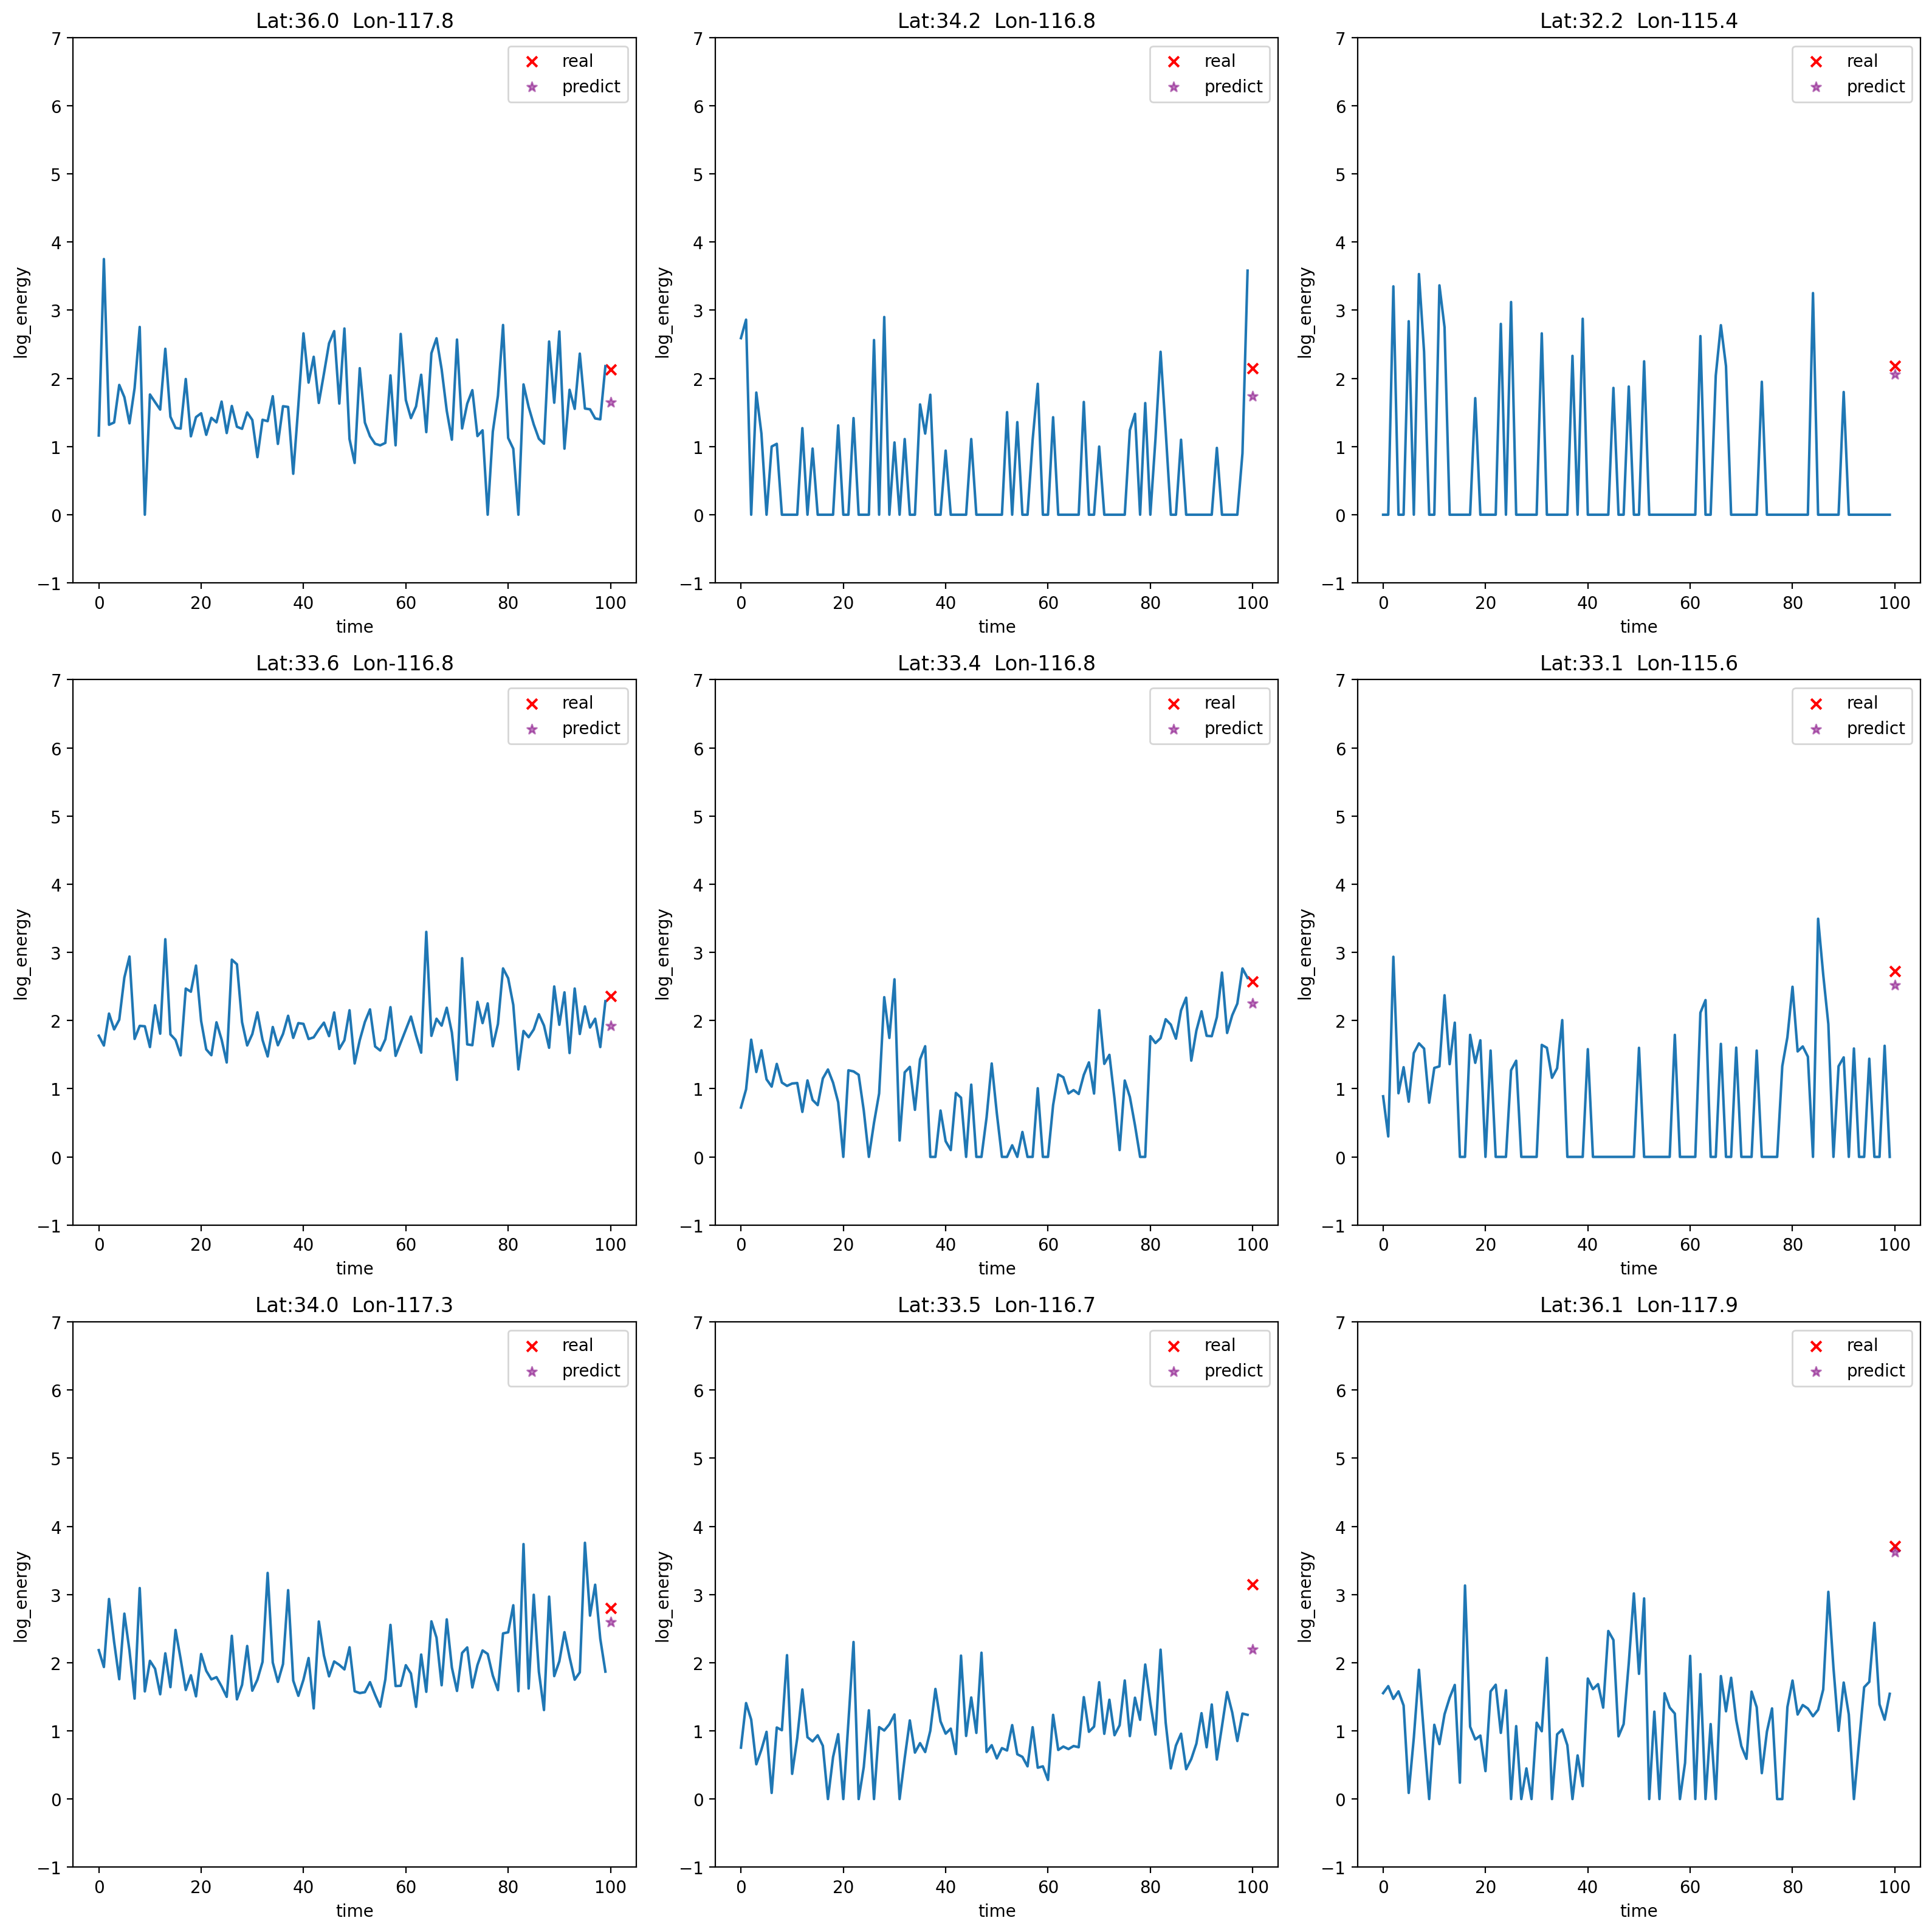

In [10]:
plt.figure(figsize=(16,16),dpi=200)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(range(len(earthquake_history_topk[:,i])),earthquake_history_topk[:,i])
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(earthquake_future_topk[:,i])),earthquake_future_topk[:,i],c='r',marker='x',label='real')
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(energy_predict[:,i])),energy_predict[:,i],c='purple',marker='*',label='predict',alpha=0.5)
    plt.title('Lat:'+str(earthquake_location_topk[i][0])+'  Lon'+str(earthquake_location_topk[i][1]))
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('log_energy')
    plt.ylim(-1,7)
plt.tight_layout()
plt.show()

In [11]:
energy_predict_all = []
earthquake_future_all = []
energy_history_all = []
earthquake_happen_all = []
with torch.no_grad():
    for batch in use_loader:
        predictions = model.predict_step(batch, 0)
        energy_predict_all.append(predictions['energy_predict'])
        earthquake_future_all.append(predictions['log_energy_future'])
        energy_history_all.append(batch['log_energy_history'])
        earthquake_happen_all.append(batch['earthquake_happen'])
energy_predict_all = torch.cat(energy_predict_all)
earthquake_future_all = torch.cat(earthquake_future_all)
energy_history_all = torch.cat(energy_history_all)
earthquake_happen_all = torch.cat(earthquake_happen_all)


TPR (Recall): 0.71
TNR (Specificity): 1.00
Precision: 0.87
Accuracy: 0.99
Error: 0.01
FPR: 0.00
Aggregative Score: 0.86


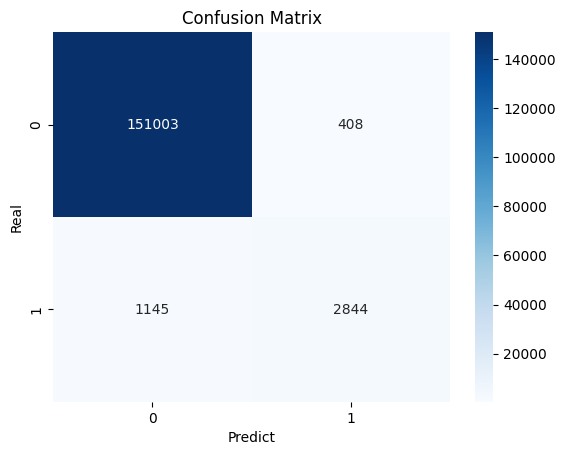

In [12]:
energy_predict,earthquake_target = plot_confusion_matrix(energy_predict_all,earthquake_future_all,threshold=3)

In [13]:
def plot_error(energy_predict, earthquake_target, error): 
    plt.figure(figsize=(12, 10))
    
    # 绘制散点图，颜色与 Real Log Energy 大小相关
    scatter = plt.scatter(
        earthquake_target, energy_predict, 
        c=earthquake_target, cmap='coolwarm', 
        alpha=0.6, label="Data points"
    )

    # 绘制基准线 y = x
    x = np.linspace(0, 7, 100)
    plt.plot(x, x, color="purple", linestyle="-", label="y=x")

    # 绘制 10% 误差线
    plt.plot(x, (1 + error) * x, color="gray", linestyle="--", label=f"{error * 100}% error bounds")
    plt.plot(x, (1 - error) * x, color="gray", linestyle="--")

    # 填充误差范围
    plt.fill_between(x, (1 - error) * x, (1 + error) * x, color="gray", alpha=0.2)

    # 图表设置
    plt.xlabel("Real Log Energy", fontsize=14)
    plt.ylabel("Predicted Log Energy", fontsize=14)
    plt.title("Scatter Error", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.xlim(-0.2, 7)
    plt.ylim(-0.2, 7)

    # 添加颜色条
    cbar = plt.colorbar(scatter)
    cbar.set_label("Real Log Energy", fontsize=12)

    # 显示图表
    plt.show()

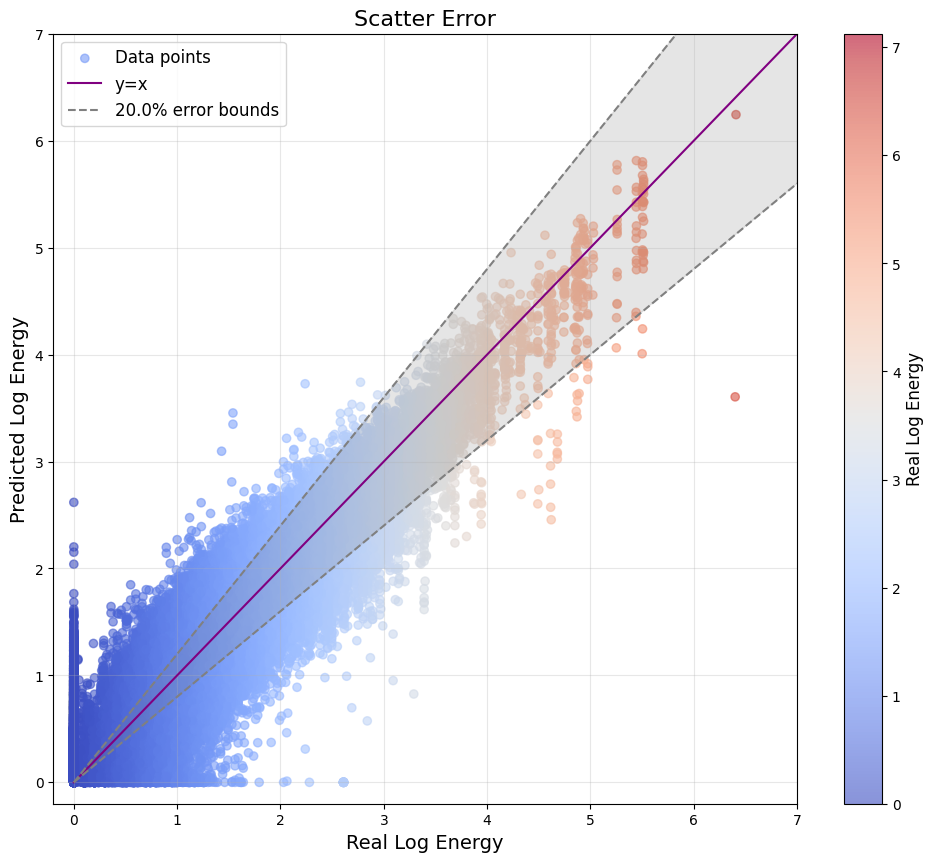

In [14]:
plot_error(energy_predict,earthquake_target,0.2)

In [15]:
energy_history_last = energy_history_all[:,-1,:,:].flatten().detach().cpu().numpy()

In [16]:
delta_energy_predict = energy_predict - energy_history_last
delta_energy_target = earthquake_target - energy_history_last

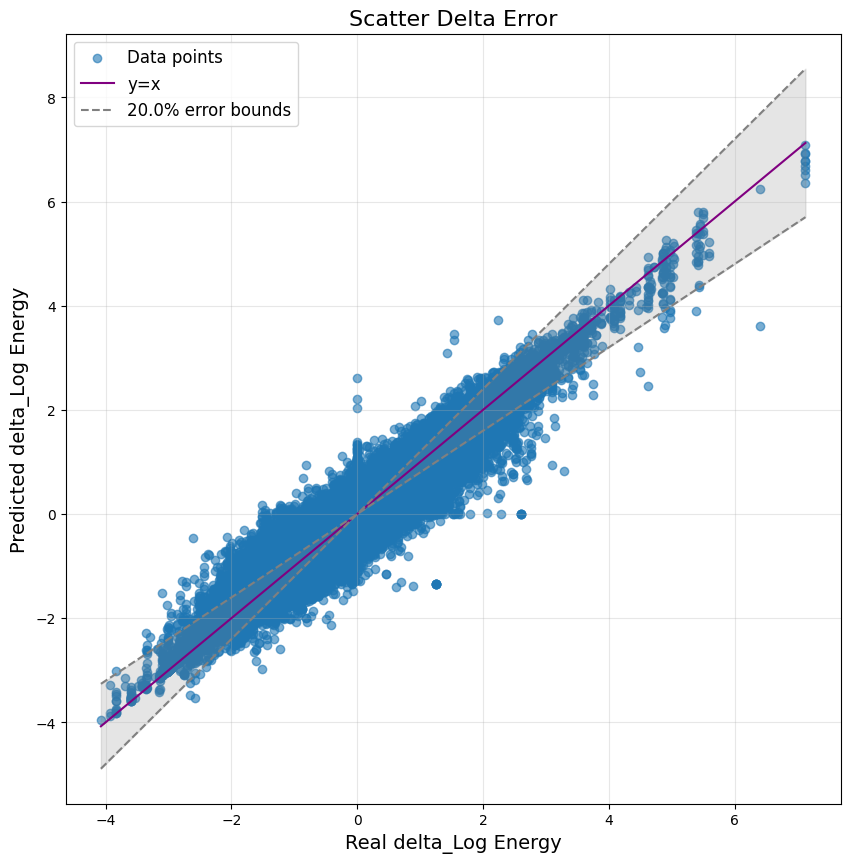

In [17]:
plot_delta_error(delta_energy_predict,delta_energy_target,0.2)

In [18]:
mse =np.power((energy_predict - earthquake_target),2).mean()
rmse = np.sqrt(mse)
nse = 1 - (np.sum(np.power((earthquake_target - energy_predict), 2)) / np.sum(np.power((earthquake_target - np.mean(earthquake_target)), 2)))
nnse = 1/(2-nse)
print("nnse:",nnse)
print('rmse:', rmse)
print('mse:', mse)

nnse: 0.930550480399791
rmse: 0.2587391
mse: 0.06694593
